In [1]:
import pandas as pd
df = pd.read_csv("../database/films_data.csv")

# Dataset structure

## 1. Features explanation

- **id** - Unique numerical identifier for the movie in the Filmweb database.
- **title** - The Polish title of the movie as it appears on the site.
- **originalTitle** - The title in its original language of production.
- **url** - Direct link to the movie’s profile page on Filmweb.pl.
- **poster_url** - Direct link to the image file of the movie's official poster.
- **year** - The official release or production year.
- **duration** - Total runtime of the movie in minutes.
- **genres** - Categories/genres assigned to the film
-------------
- **production_country** - Country or countries where the film was produced.
- **directors** - List of directors.
- **creators** - List of creators
- **based_on** -List of original source material.
- **studio** - List of studios involved.
-------------
- **desc_short** - A brief tagline or short synopsis of the movie.
- **desc_long** - The comprehensive, detailed plot summary.
-------------
- **vod** - Information regarding the film's availability on streaming/Video On Demand platforms.
-------------
- **worldReleaseDate** - The date of the very first screening anywhere in the world (often festivals).
- **worldPublicReleaseDate** - The date the movie was released to the general public worldwide.
- **releaseDatePoland** - The official premiere date in Polish cinemas.
-------------
- **rate** - The average user rating on a scale of 1 to 10.
- **rate_count** - The total number of users who have submitted a rating.
- **critic_rate** - The average score based on professional film critics' reviews.
- **critic_count** - The total number of professional reviews recorded.
- **countWantToSee** - The number of users who have added the movie to their "Want to see" list.
-------------
- **budget** - The estimated cost of producing the film (usually in USD).
- **boxoffice_in_usa** - Total gross revenue earned from theaters in the United States.
- **boxoffice_outside_usa** - Total gross revenue earned from international markets (excluding the USA).
- **boxoffice_world** - Total worldwide gross revenue (the sum of USA and international earnings).
-------------


## 2. load data

In [2]:
import pandas as pd
df = pd.read_csv("../database/films_data.csv")

In [3]:
print(f"Rekords: {df.shape[0]}")

Rekords: 732450


## 3. Missing Value Heatmap

In [4]:
missing_data = pd.DataFrame({
    'count': df.isna().sum(),
    'percent (%)': (df.isna().mean() * 100).round(2)
})

missing_data

,count,percent (%)
id,0,0.00
title,645404,88.12
originalTitle,1,0.00
url,19,0.00
poster_url,493298,67.35
year,0,0.00
duration,220811,30.15
genres,70143,9.58
production_country,39376,5.38
directors,282315,38.54


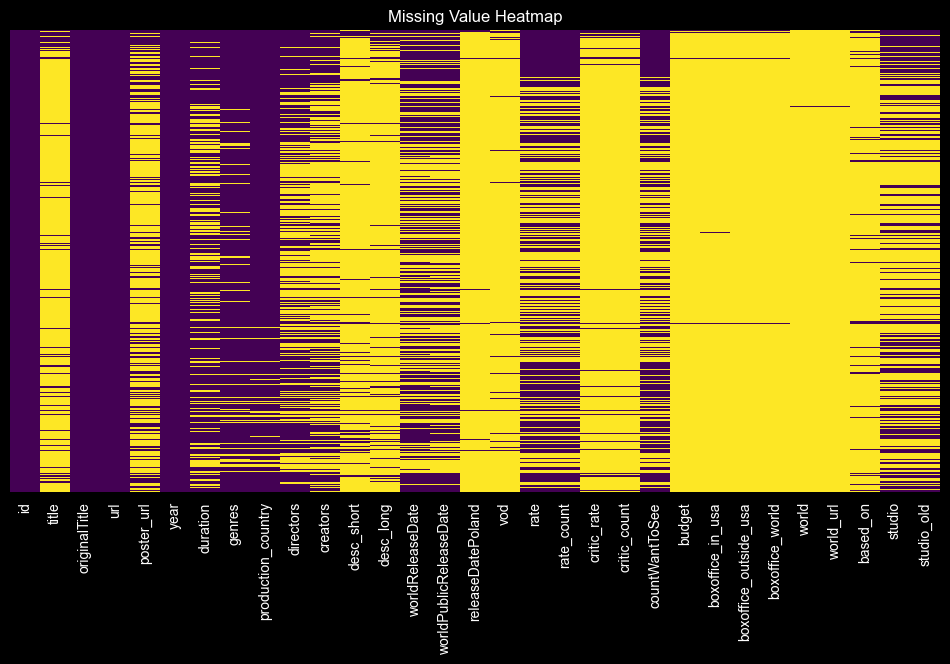

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')

plt.title('Missing Value Heatmap')
plt.show()

The chart illustrates significant missing values within the dataset. However, this is due to the varying popularity of films and the sheer scale of the data.

## 4. Numerical preview

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,732450.0,1.394733e+06,2.853382e+06,1.0,289697.25,497445.5,723838.75,1.011972e+07
year,732450.0,1.986603e+03,3.377190e+01,1888.0,1968.00,2001.0,2012.00,2.035000e+03
duration,511639.0,6.265318e+01,1.067167e+02,0.0,18.00,73.0,93.00,5.142000e+04
worldReleaseDate,417754.0,1.984857e+07,3.647834e+05,0.0,19611022.25,20020910.0,20120400.00,2.031122e+07
worldPublicReleaseDate,381955.0,1.982429e+07,3.699219e+05,0.0,19561126.00,20000316.0,20101105.00,2.031122e+07
releaseDatePoland,13383.0,2.008476e+07,2.020971e+05,18000101.0,20040316.50,20140404.0,20211107.00,2.029122e+07
rate,431497.0,4.008669e+00,3.106641e+00,0.0,0.00,5.0,6.50,1.000000e+01
rate_count,431497.0,9.594313e+02,1.216982e+04,0.0,0.00,2.0,13.00,1.048255e+06
critic_rate,40093.0,5.786628e+00,1.680820e+00,0.0,5.00,6.0,7.00,1.000000e+01
critic_count,40093.0,6.326092e+00,1.116898e+01,0.0,1.00,2.0,6.00,9.800000e+01


Most of the data points show expected values; however, with such a large dataset, certain anomalies are to be expected—such as the minimum value for "countWantToSee" being -188, which is logically impossible.

## 5. Categorical Data Analysis

In [15]:
def display_unique_cat_vals(series, label, sep=",", max_list_len=250):
    unique_values = (
        series
        .str.split(sep)
        .explode()
        .str.strip()
        .unique()
    )

    print(f"{label}: {len(unique_values)}\n")

    print_end = ", ..." if len(unique_values) > max_list_len else "\n"
    print("Unique values: \n", ", ".join(unique_values[:max_list_len].astype(str)), print_end)

## Genres

In [8]:
display_unique_cat_vals(df["genres"], "Genres")

Genres: 61

Unique values: 
 Thriller, Akcja, Melodramat, Wojenny, Komedia, Musical, Biograficzny, Dramat, Muzyczny, Obyczajowy, Familijny, Przygodowy, Animacja, Horror, Sensacyjny, Sci-Fi, Psychologiczny, Katastroficzny, Dramat historyczny, Komedia kryminalna, Dramat obyczajowy, Romans, Czarna komedia, Kostiumowy, Dla dzieci, Kryminał, Gangsterski, Komedia rom., Sportowy, Fantasy, Dokumentalny, Satyra, Baśń, Komedia obycz., Historyczny, Świąteczny, Krótkometrażowy, Przyrodniczy, Religijny, Dla młodzieży, Erotyczny, Biblijny, Surrealistyczny, Western, Anime, Polityczny, Dokumentalizowany, Poetycki, Niemy, Film-Noir, Dramat sądowy, Animacja dla dorosłych, Dreszczowiec, nan, Fabularyzowany dok., Propagandowy, Szpiegowski, Groteska filmowa, Sztuki walki, XXX, True crime 



## Production countries

In [9]:
display_unique_cat_vals(df["production_country"], "Production countries")

Production countries: 216

Unique values: 
 US, FR, JP, DE, GB, AU, BE, NL, IE, PL, HU, DK, SE, IT, MX, ES, CH, AT, IN, NZ, IS, NO, CA, AR, CZ, SK, HK, GR, XFY, CN, BR, PE, AW, MA, MC, RU, LU, RO, KE, CU, XWG, IL, KR, XCS, IR, MK, TR, ZA, MT, PT, BG, LI, TN, UA, XSU, GE, FO, UZ, TJ, NP, HR, VE, SG, TW, FI, XYU, ZW, XEG, PH, CY, nan, CI, NA, CO, ID, BY, TH, SI, AL, EG, KZ, EC, PA, MY, HT, VN, CL, PR, MD, JO, UY, BW, BA, KG, GH, BT, DZ, MZ, TT, BO, JM, XSM, LT, ML, LB, LY, KW, SA, DO, SN, AE, EE, AZ, LV, AM, XPI, MN, MR, TD, AO, BB, AF, SY, KP, TM, PK, KH, BS, ZM, MG, NI, CR, NE, CG, GT, VA, CM, TZ, EH, LK, NG, BF, GA, RW, XZR, MQ, GN, GW, IQ, BJ, CD, ET, BD, PY, RS, XSI, GL, SR, AD, SV, CV, XVN, FJ, PG, ER, DJ, SO, LA, HN, MU, YE, SC, TG, SD, XBU, BH, BZ, AG, LS, GP, XKO, GY, BI, CF, TO, UG, OM, LR, SL, NU, MO, QA, ME, VC, XKV, MW, SZ, DM, GD, KM, WS, SM, MV, GM, FM, PW, KI, LC, MH, TV, GQ, VU, BN, PS, MM, KN 



## Directors

In [10]:
display_unique_cat_vals(df["directors"], "Directors")

Directors: 158908

Unique values: 
 Kevin Reynolds, Kevin Hooks, Anthony Minghella, John Landis, Scott Hicks, Jeroen Krabbé, Michael Winterbottom, Jim Sheridan, Don Bluth, Gary Goldman, János Szász, Stephen Norrington, Wolfgang Petersen, Bille August, Robert Duvall, Paul Thomas Anderson, George Miller, Michael Bay, Steven Spielberg, Taylor Hackford, Joel Coen, Gus Van Sant, Agnieszka Holland, Neil Jordan, Woody Allen, Radosław Piwowarski, Mike van Diem, Terrence Malick, Quentin Tarantino, Allison Anders, Robert Harling, Wayne Wang, James Mangold, Randall Wallace, Irwin Winkler, Steven Soderbergh, Duncan McLachlan, F. Gary Gray, Jan Kounen, Władysław Pasikowski, Robert Rodriguez, John Lasseter, Andrew Stanton, Pedro Almodóvar, Fred Gerber, Trish McAdam, John McNaughton, Mimi Leder, Steve Rash, Andy Tennant, Barry Levinson, Michał Rosa, Jon Avnet, Les Mayfield, Claude Chabrol, Michael Haneke, Ridley Scott, Paul W.S. Anderson, Marcin Ziębiński, Peter Medak, Peter Berg, Brett Ratner, Rolan

## Creators

In [11]:
display_unique_cat_vals(df["creators"], "Creators")

Creators: 192120

Unique values: 
 Scott Yagemann, William Mickelberry, Dan Vining, Anthony Minghella, John Landis, Dan Aykroyd, Jan Sardi, Edwin de Vries, Frank Cottrell Boyce, Terry George, Jim Sheridan, Susan Gauthier, Noni White, János Szász, András Szeredás, David S. Goyer, Andrew W. Marlowe, Ann Biderman, Robert Duvall, Paul Thomas Anderson, George Miller, Judy Morris, Tony Gilroy, J.J. Abrams, David Franzoni, Jonathan Lemkin, Ethan Coen, Joel Coen, Ben Affleck, Matt Damon, Christopher Hampton, Pat McCabe, Neil Jordan, Woody Allen, Radosław Piwowarski, Laurens Geels, Ruud van Megen, Terrence Malick, Allison Anders, Quentin Tarantino, Robert Harling, Larry Gross, Jean-Claude Carrière, James Mangold, Randall Wallace, Steve Levitt, Oliver Sacks, Scott Frank, Bayard Johnson, Matthew Horton, Kate Lanier, Takashi Bufford, Joël Houssin, Władysław Pasikowski, Robert Rodriguez, Andrew Stanton, Don McEnery, Pedro Almodóvar, Ray Loriga, Paul Bernbaum, Trish McAdam, Stephen Peters, Bruce Joe

## Based on

In [18]:
display_unique_cat_vals(df["based_on"], "based_on", sep="/")

based_on: 38716

Unique values: 
 nan, Michael Ondaatje  (powieść), Scott Hicks  (opowiadanie), Carl Friedman  (powieść), Michael Nicholson  (książka), Géza Csáth  (opowiadanie), Marv Wolfman  (postacie), Gene Colan  (postacie), Peter Høeg  (powieść), Robert Roy Pool  (materiały do scenariusza, historia), Jonathan Hensleigh  (materiały do scenariusza, historia), Andrew Neiderman  (powieść), Pat McCabe  (powieść), James Jones  (powieść), Larry McMurtry  (powieść), Aleksander Dumas ojciec  (powieść), Elmore Leonard  (powieść), Rudyard Kipling  (powieść), Joe Ranft  (materiały do scenariusza, historia), John Lasseter  (materiały do scenariusza, historia)  ...więcej, Ruth Rendell  (powieść), Steve Zacharias  (materiały do scenariusza, historia), Jeff Buhai  (materiały do scenariusza, historia)  ...więcej, Charles Perrault  (książka), Larry Beinhart  (książka), Samuel W. Taylor  (opowiadanie), Danielle Alexandra  (materiały do scenariusza, historia), Dennis Feldman  (postacie), Ross LaManna

## Studio

In [16]:
display_unique_cat_vals(df["studio"], "Studios", sep="/")

Studios: 95584

Unique values: 
 Icon Entertainment International, R U Dun Productions, Mutual Film Company, Universal Pictures, Black Dog Productions, Miramax Films, Tiger Moth Productions, Australian Film Finance Corporation (AFFC), Film Victoria, South Australian Feature Film Company, CoBo Fonds, Creative Investment, De Vensche, Channel Four Films, Dragon Pictures, Twentieth Century Fox Film Corporation, Big Gun Project, The, Fox Animation Studios, 47ème Parallèle, Budapest Filmstúdió, Mafilm, Amen Ra Films, Imaginary Forces, Marvel Enterprises, Beacon Communications, Columbia Pictures Corporation, Radiant Productions, Bavaria Film, Constantin Film Produktion, Det Danske Filminstitut, Butchers Run Films, New Line Cinema, Ghoulardi Film Company, Lawrence Gordon Productions, Kennedy Miller Productions, Touchstone Pictures, Disney, Jerry Bruckheimer Films, DreamWorks SKG, Home Box Office (HBO), Warner Bros., Kopelson Entertainment, Monarchy Enterprises B.V., PolyGram Filmed Entertainme

## Vod options

In [13]:
display_unique_cat_vals(df["vod"], "Vod options")

Vod options: 28

Unique values: 
 CDA.pl, nan, Apple TV+, Player, Prime Video, Canal+, Gonet.tv, Megogo, WP Pilot, Disney+, Rakuten TV, Play Now, SkyShowtime, Netflix, TVP VOD, HBO Max, TV Smart, Nowe Horyzonty, Filmbox+, 35mm.online, Flixclassic, Polsat Box Go, Pięć Smaków, Katoflix, Red GO, MojeeKino.pl, E-Kino Pod Baranami, Ninateka 

